# Import

In [29]:
import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# sklearn
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier 
from sklearn.naive_bayes import GaussianNB 
from sklearn.svm import SVC 
from sklearn.ensemble import (
    RandomForestClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    KFold, 
    cross_val_score,
    cross_validate
)
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

# Init

In [30]:
def calc_cv(MODEL):
    model = MODEL
    results = cross_validate(
        model,
        x_train, 
        y_train,
        cv=5,
        scoring=('accuracy', 'f1'),
        return_train_score=True
    )
    output_str = f"""
    {model}
    Median F1-score (5-fold CV): {np.median(results['test_f1']):.3f}
    (accuracy: {np.median(results['test_accuracy']):.3f})
    """
    print(output_str)
    return None


In [31]:
def performance_metrics(model, true_labels, features_to_predict):
    predictions = model.predict( features_to_predict )
    print(f"Performance metrics of the model {model}:")
    print(f" - Accuracy = {accuracy_score( true_labels, predictions ):.3f}")
    print(f" - Precision = {precision_score( true_labels, predictions ):.3f}")
    print(f" - Recall = {recall_score( true_labels, predictions ):.3f}")
    print(f" - F1 = {f1_score( true_labels, predictions ):.3f}")
    return None

# Read

In [32]:
df_raw = pd.read_csv('data/train.csv')
df_raw.head(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S


# EDA

In [33]:
print(f"Rows: {len(df_raw)}")
print(f"Variables: {len(list(df_raw.columns))} : {list(df_raw.columns)}")
numeric_columns = list(df_raw._get_numeric_data().columns)
categorical_columns = [i for i in list(df_raw.columns) if i not in numeric_columns]
print(f" - Numeric columns: {len(numeric_columns)}")
for i in numeric_columns: print("    - ", i)
print(f" - Categorical columns: {len(categorical_columns)}")
for i in categorical_columns: print("    - ", i)

Rows: 891
Variables: 12 : ['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked']
 - Numeric columns: 7
    -  PassengerId
    -  Survived
    -  Pclass
    -  Age
    -  SibSp
    -  Parch
    -  Fare
 - Categorical columns: 5
    -  Name
    -  Sex
    -  Ticket
    -  Cabin
    -  Embarked


Text(0.5, 1.0, 'Survived (1) vs deceased (0)')

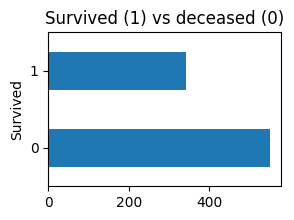

In [34]:
df_raw['Survived'].value_counts().plot(kind='barh', figsize=(3,2))
plt.title('Survived (1) vs deceased (0)')

## Numerical

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
0,1,0,3,22.0,1,0,7.2500
1,2,1,1,38.0,1,0,71.2833
2,3,1,3,26.0,0,0,7.9250


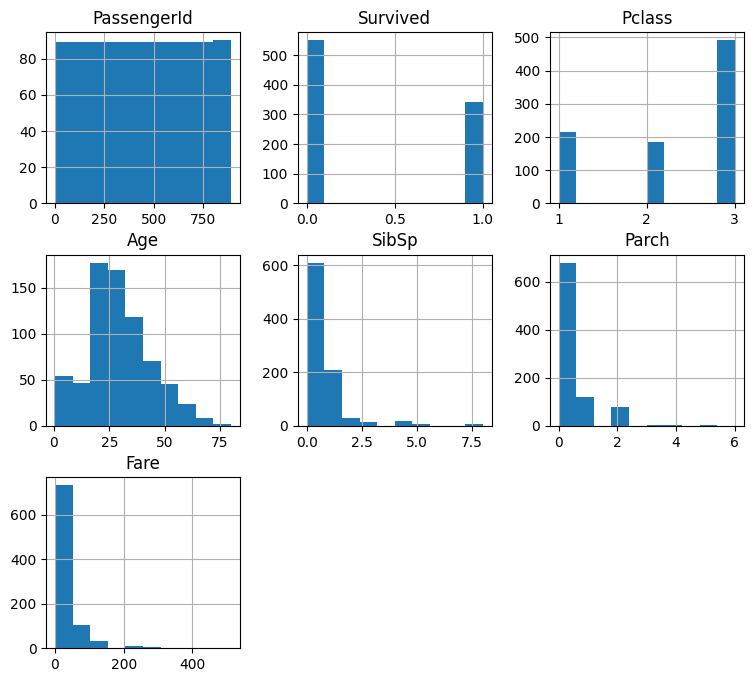

In [35]:
# Describe numerical variables
display( df_raw[numeric_columns].head(3) )
df_raw.hist(figsize=(9,8));

thoughts:
- remove "PassengerId"


## Categorical

In [36]:
# Describe categorical variables 
display( df_raw[categorical_columns].head(3) )
for i in categorical_columns:
    header = f"--- {i} ------------------------"
    print('-'*len(header))
    print(header)
    print('-'*len(header))
    how_many_categorires = len(df_raw[i].value_counts().tolist())
    print(f'Number of categories: {how_many_categorires}')
    if how_many_categorires < 10:
        print(df_raw[i].value_counts())


,Name,Sex,Ticket,Cabin,Embarked
0,"Braund, Mr. Owen Harris",male,A/5 21171,NaN,S
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,PC 17599,C85,C
2,"Heikkinen, Miss. Laina",female,STON/O2. 3101282,NaN,S


---------------------------------
--- Name ------------------------
---------------------------------
Number of categories: 891
--------------------------------
--- Sex ------------------------
--------------------------------
Number of categories: 2
Sex
male      577
female    314
Name: count, dtype: int64
-----------------------------------
--- Ticket ------------------------
-----------------------------------
Number of categories: 681
----------------------------------
--- Cabin ------------------------
----------------------------------
Number of categories: 147
-------------------------------------
--- Embarked ------------------------
-------------------------------------
Number of categories: 3
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


thoughts: 
- remove "Name", "Ticket", "Cabin"
- "Sex", "Embarked" could be one-hot encoded



# Data Preproc

## Train-val-test split

In [37]:
df_train = df_raw.copy(deep=True)

## Cleaning

In [38]:
# how many null values are there
df_raw.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

We will do the following:
- Drop "Cabin" - too many missing values
- "Age" - fill with average 
- "Embarked" - create new class "U" - unknown

In [39]:
def pipeline_1_clean(DF):
    ### Handling missing values
    # Drop "Cabin"
    DF = DF.drop(['Cabin'], axis=1)
    # "Age" - fill with average
    DF['Age'] = DF['Age'].fillna(DF['Age'].mean())
    # "Embarked" - fillna with "U" (unknown)
    DF['Embarked'] = DF['Embarked'].fillna('U')
    ### Removing unnecessary columns
    # Drop "PassengerId", "Name", "Ticket", "Cabin"
    DF = DF.drop(['PassengerId', 'Name', 'Ticket'], axis=1)
    ### 
    return DF

df_train_preproc1 = pipeline_1_clean(df_train)
display( df_train_preproc1.head(3) )
df_train_preproc1.isna().sum()


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,0,3,male,22.0,1,0,7.2500,S
1,1,1,female,38.0,1,0,71.2833,C
2,1,3,female,26.0,0,0,7.9250,S


Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

## Feature engineering

In [40]:
# "Sex", "Embarked" could be one-hot encoded

def pipeline_2_feature(DF):
    ### One-hot encode features
    for i in ['Sex', 'Embarked']:
        columns = pd.get_dummies(DF[i], prefix=i)
        DF = pd.concat([DF, columns], axis=1)
        DF = DF.drop([i], axis=1)
    for i in ['Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Embarked_U']:
        if i not in list(DF.columns):
            DF[i] = False
    ### Log normalise 'Fare' and 'Age'
    for i in ['Fare', 'Age']:
        DF[i] = DF[i].replace(0, 0.1)
        DF[i] = np.log10(DF[i])
    return DF

df_train_preproc2 = pipeline_2_feature(df_train_preproc1)
df_train_preproc2.head(5)

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_U
0,0,3,1.342423,1,0,0.860338,False,True,False,False,True,False
1,1,1,1.579784,1,0,1.852988,True,False,True,False,False,False
2,1,3,1.414973,0,0,0.898999,True,False,False,False,True,False
3,1,1,1.544068,1,0,1.725095,True,False,False,False,True,False
4,0,3,1.544068,0,0,0.905796,False,True,False,False,True,False


In [41]:
def pipeline_3_preproc(DF):
    # Split to features and labels
    if 'Survived' in list(DF.columns):
        x = DF.drop(['Survived'], axis=1)
        y = DF['Survived']
    # if the col 'Survived' is not present, then it's the Kaggle test set 
    else:
        x = DF.copy(deep=True)
        y = None
    # Order 
    x = x[['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_female', 'Sex_male', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Embarked_U']]
    return x, y

x_train, y_train = pipeline_3_preproc(df_train_preproc2)
display(x_train.shape)
display(y_train.shape)


(891, 11)

(891,)

In [42]:
def pipeline_full(DF: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    df_preproc1 = pipeline_1_clean(DF)
    df_preproc2 = pipeline_2_feature(df_preproc1)
    x, y = pipeline_3_preproc(df_preproc2)
    return x, y

x_train, y_train = pipeline_full(df_train)
display(x_train.shape, y_train.shape)

(891, 11)

(891,)

# Models

## Train

In [43]:
calc_cv(
    LogisticRegression()
)


    LogisticRegression()
    Median F1-score (5-fold CV): 0.722
    (accuracy: 0.788)
    


In [44]:
from sklearn.metrics import f1_score, make_scorer

grid = {
    "penalty": ["l1", "l2", "elasticnet", None],
    "tol": [0.00001, 0.0001, 0.001, 0.01, 0.1, 1, 5, 10], 
    "solver": ['lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'],
    "C": [1, 1.1, 1.3, 1.5, 2, 3],
    "max_iter": [100, 300, 500, 1000]
}
f1 = make_scorer(f1_score)

cv_grid = GridSearchCV(
    LogisticRegression(), 
    grid,
    cv=5,
    scoring=f1,
    n_jobs=-1
)
cv_grid.fit(x_train, y_train)
model_logreg_gs = cv_grid.best_estimator_
calc_cv(model_logreg_gs)

C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
10560 fits failed out of a total of 23040.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
960 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2k


    LogisticRegression(C=1, max_iter=300, penalty='l1', solver='saga', tol=1e-05)
    Median F1-score (5-fold CV): 0.731
    (accuracy: 0.793)
    


C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\linear_model\_sag.py:349: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


In [45]:
calc_cv(
    DecisionTreeClassifier()
)


    DecisionTreeClassifier()
    Median F1-score (5-fold CV): 0.696
    (accuracy: 0.764)
    


In [46]:
grid = {
    "max_depth": [1, 2, 3, 4, 5, None],
    "min_samples_split": [2, 5, 10, 15, None],
    "min_samples_leaf": [1, 3, 5, 10, None],
    "max_leaf_nodes": [1, 3, 5, 10, 15, None]
}
f1 = make_scorer(f1_score)
cv_grid = GridSearchCV(
    DecisionTreeClassifier(),
    grid,
    cv=5,
    scoring=f1,
    n_jobs=-1
)
cv_grid.fit(x_train, y_train)
model_decisiontree_gs = cv_grid.best_estimator_
calc_cv(model_decisiontree_gs)


    DecisionTreeClassifier(max_leaf_nodes=15, min_samples_split=15)
    Median F1-score (5-fold CV): 0.754
    (accuracy: 0.821)
    


C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py:540: FitFailedWarning: 
2100 fits failed out of a total of 4500.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
750 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\model_selection\_validation.py", line 888, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfr

In [47]:
calc_cv(GaussianNB())


    GaussianNB()
    Median F1-score (5-fold CV): 0.300
    (accuracy: 0.685)
    


In [48]:
calc_cv(SVC())


    SVC()
    Median F1-score (5-fold CV): 0.758
    (accuracy: 0.820)
    


In [49]:
from sklearn.metrics import f1_score, make_scorer

grid = {
    "C": [0.1, 0.5, 0.7, 1, 1.5, 2],
    "kernel": ['linear', 'poly', 'rbf', 'sigmoid'],
    "degree": [1, 2, 3, 4, 5, 6],
    "gamma": ["scale", "auto"]
}
f1 = make_scorer(f1_score)

cv_grid = GridSearchCV(
    SVC(), 
    grid,
    cv=5,
    scoring=f1,
    n_jobs=-1
)
cv_grid.fit(x_train, y_train)
model_svc_gs = cv_grid.best_estimator_
calc_cv(model_svc_gs)


    SVC(C=0.1, degree=5, kernel='poly')
    Median F1-score (5-fold CV): 0.770
    (accuracy: 0.827)
    


In [50]:
calc_cv(RandomForestClassifier())


    RandomForestClassifier()
    Median F1-score (5-fold CV): 0.744
    (accuracy: 0.815)
    


In [51]:
from sklearn.metrics import f1_score, make_scorer

grid = {
    "n_estimators": [50, 100, 150, 200],
    "max_depth": [None, 3, 5, 10, 15],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 5, 10, 15, 20],
    'max_leaf_nodes': [None, 5, 10, 15, 20]
}
f1 = make_scorer(f1_score)

cv_grid = GridSearchCV(
    RandomForestClassifier(), 
    grid,
    cv=5,
    scoring=f1,
    n_jobs=-1
)
cv_grid.fit(x_train, y_train)
model_randomforest_gs = cv_grid.best_estimator_
calc_cv(model_randomforest_gs)


    RandomForestClassifier(min_samples_split=5, n_estimators=50)
    Median F1-score (5-fold CV): 0.738
    (accuracy: 0.809)
    


In [52]:
calc_cv(GradientBoostingClassifier())


    GradientBoostingClassifier()
    Median F1-score (5-fold CV): 0.762
    (accuracy: 0.831)
    


In [53]:
grid = {
    "learning_rate": [0.001, 0.01, 0.1, 0.5],
    "n_estimators": [50, 100, 150, 200],
    "min_samples_split": [2, 5, 10, 15],
    "min_samples_leaf": [1, 3, 5, 10, 15],
    "max_depth": [3, 5, 10, 12]
}
f1 = make_scorer(f1_score)

cv_grid = GridSearchCV(
    GradientBoostingClassifier(), 
    grid,
    cv=5,
    scoring=f1,
    n_jobs=-1
)
cv_grid.fit(x_train, y_train)
model_gradientboost_gs = cv_grid.best_estimator_
calc_cv(model_gradientboost_gs)


    GradientBoostingClassifier(learning_rate=0.5, min_samples_leaf=3,
                           n_estimators=50)
    Median F1-score (5-fold CV): 0.772
    (accuracy: 0.837)
    


In [54]:
calc_cv(AdaBoostClassifier())

C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algor


    AdaBoostClassifier()
    Median F1-score (5-fold CV): 0.735
    (accuracy: 0.809)
    


C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


In [55]:
grid = {
    "learning_rate": [0.001, 0.01, 0.1, 0.5, 1, 3, 5],
    "n_estimators": [15, 30, 50, 100, 150, 200, 250]
}
f1 = make_scorer(f1_score)

cv_grid = GridSearchCV(
    AdaBoostClassifier(), 
    grid,
    cv=5,
    scoring=f1,
    n_jobs=-1
)
cv_grid.fit(x_train, y_train)
model_adaboost_gs = cv_grid.best_estimator_
calc_cv(model_adaboost_gs)


C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(
C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algor


    AdaBoostClassifier(learning_rate=1, n_estimators=250)
    Median F1-score (5-fold CV): 0.754
    (accuracy: 0.815)
    


In [56]:
from sklearn.neural_network import MLPClassifier 

nn_model = MLPClassifier(
    activation='relu',
    solver='adam',
    max_iter=1000
)
calc_cv(nn_model)


    MLPClassifier(max_iter=1000)
    Median F1-score (5-fold CV): 0.736
    (accuracy: 0.821)
    


In [57]:
grid = {
    "hidden_layer_sizes": [(100,), (100,50), (100,100,50)],
    "solver": ['adam', 'lbfgs', 'sgd'],
    "learning_rate": ['constant', 'invscaling', 'adaptive'],
    "early_stopping": [True, False]
}
f1 = make_scorer(f1_score)

cv_grid = GridSearchCV(
    MLPClassifier(), 
    grid,
    cv=5,
    scoring=f1,
    n_jobs=-1
)
cv_grid.fit(x_train, y_train)
model_nn_gs = cv_grid.best_estimator_
calc_cv(model_nn_gs)


C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(



    MLPClassifier(hidden_layer_sizes=(100, 100, 50), learning_rate='invscaling')
    Median F1-score (5-fold CV): 0.723
    (accuracy: 0.798)
    


C:\Users\Evgeni Zorin\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


# Save model

In [59]:
pickle.dump(
    model_gradientboost_gs, 
    open(f"data/model/250430_v3_ML_model_Titanic.sav", 'wb')
)

# Make prediction on the Kaggle test set

In [60]:
df_kaggle_test = pd.read_csv('data/test.csv')
df_kaggle_test

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


In [61]:
x_kaggle_test, _ = pipeline_full(df_kaggle_test)
x_kaggle_test

,Pclass,Age,SibSp,Parch,Fare,Sex_female,Sex_male,Embarked_C,Embarked_Q,Embarked_S,Embarked_U
0,3,1.537819,0,0,0.893717,False,True,False,True,False,False
1,3,1.672098,1,0,0.845098,True,False,False,False,True,False
2,2,1.792392,0,0,0.986212,False,True,False,True,False,False
3,3,1.431364,0,0,0.937643,False,True,False,False,True,False
4,3,1.342423,1,1,1.089464,True,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...
413,3,1.481050,0,0,0.905796,False,True,False,False,True,False
414,1,1.591065,0,0,2.037028,True,False,True,False,False,False
415,3,1.585461,0,0,0.860338,False,True,False,False,True,False
416,3,1.481050,0,0,0.905796,False,True,False,False,True,False


In [62]:
display( x_kaggle_test.isna().sum() )
x_kaggle_test_2 = x_kaggle_test.copy(deep=True)
x_kaggle_test_2['Fare'] = x_kaggle_test['Fare'].fillna(x_kaggle_test['Fare'].median())
display( x_kaggle_test_2.isna().sum() )

Pclass        0
Age           0
SibSp         0
Parch         0
Fare          1
Sex_female    0
Sex_male      0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
Embarked_U    0
dtype: int64

Pclass        0
Age           0
SibSp         0
Parch         0
Fare          0
Sex_female    0
Sex_male      0
Embarked_C    0
Embarked_Q    0
Embarked_S    0
Embarked_U    0
dtype: int64

In [63]:
predictions = list(model_gradientboost_gs.predict(x_kaggle_test_2))
predictions[:5]

[0, 0, 0, 0, 0]

In [64]:
df_output = pd.DataFrame({
    'PassengerId': df_kaggle_test['PassengerId'],
    'Survived': predictions
})
df_output

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [65]:
df_output.to_csv('data/model/250430_v3_test_csv_predictions.csv', index=False)